# סימולציה של תגובה אנזימטית בעזרת SciPy\n\nבמחברת זו נשתמש ב־SciPy כדי לפתור משוואות דיפרנציאליות שמתארות תגובה כימית. הדוגמה תהיה מינימלית, אבל לא כזו שנפתור בקלות ביד: מנגנון אנזימטי פשוט עם יצירת קומפלקס ביניים.\n\nהרעיון החשוב הוא שאם אנחנו יודעים את חוקי השינוי הרגעיים, SciPy יכולה לחשב עבורנו את ההתפתחות בזמן.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## המנגנון\n\nנשתמש במנגנון אנזימטי בסיסי:\n\n$$E + S \rightleftharpoons ES \rightarrow E + P$$\n\nכאן $E$ הוא האנזים החופשי, $S$ הוא הסובסטרט, $ES$ הוא קומפלקס אנזים־סובסטרט, ו־$P$ הוא התוצר. המנגנון קצר, אבל כבר כולל כמה ריכוזים שמשפיעים זה על זה.

נסמן את קבועי הקצב כך:\n\n$$E + S \xrightarrow{k_1} ES$$\n\n$$ES \xrightarrow{k_{-1}} E + S$$\n\n$$ES \xrightarrow{k_\mathrm{cat}} E + P$$\n\nלפי חוק הפעולה ההמונית, קצב יצירת $ES$ הוא $k_1[E][S]$, ולכן המשוואות אינן כולן לינאריות. זו סיבה טובה להשתמש בפתרון נומרי.

In [2]:
k1 = 8.0      # 1/(mmol/L min)
km1 = 1.0     # 1/min
kcat = 0.7    # 1/min

def enzyme_rhs(t, y):
    S, E, ES, P = y
    binding = k1 * E * S
    unbinding = km1 * ES
    reaction = kcat * ES

    dSdt = -binding + unbinding
    dEdt = -binding + unbinding + reaction
    dESdt = binding - unbinding - reaction
    dPdt = reaction

    return [dSdt, dEdt, dESdt, dPdt]

כדי לפתור את המשוואות צריך לתת תנאי התחלה. בתחילת הניסוי יש סובסטרט ואנזים חופשי, אבל אין עדיין קומפלקס ואין תוצר.

In [3]:
S0 = 1.0   # mmol/L
E0 = 0.08  # mmol/L
ES0 = 0.0
P0 = 0.0

y0 = [S0, E0, ES0, P0]

time_span = (0, 20)
t_eval = np.linspace(time_span[0], time_span[1], 300)

solution = solve_ivp(enzyme_rhs, time_span, y0, t_eval=t_eval)

In [4]:
print(solution.success)
print(solution.message)

True
The solver successfully reached the end of the integration interval.


האובייקט `solution` מכיל את הזמנים ואת הריכוזים שחושבו. נפריד אותם למשתנים עם שמות נוחים יותר.

In [5]:
t = solution.t
S, E, ES, P = solution.y

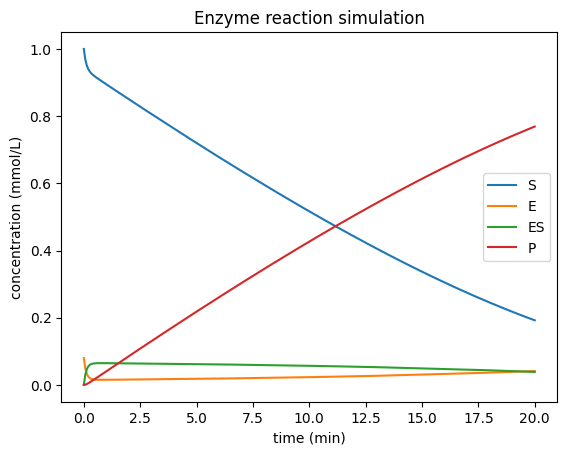

In [6]:
plt.figure()
plt.plot(t, S, label='S')
plt.plot(t, E, label='E')
plt.plot(t, ES, label='ES')
plt.plot(t, P, label='P')
plt.xlabel('time (min)')
plt.ylabel('concentration (mmol/L)')
plt.title('Enzyme reaction simulation')
plt.legend()
plt.show()

הקומפלקס $ES$ נוצר מהר יחסית ואז משתנה לאט יותר. התוצר $P$ הולך וגדל, והסובסטרט $S$ הולך ונצרך. זו בדיוק הסוגיה שבה פתרון נומרי מועיל: אפילו מנגנון קצר יוצר התנהגות לא־טריוויאלית.

## בדיקת שימור חומר\n\nסימולציה טובה צריכה גם לעבור בדיקות פשוטות. כאן כמות האנזים הכוללת אמורה להישמר:\n\n$$[E] + [ES] = \mathrm{constant}$$\n\nבנוסף, כמות החומר שמקורו בסובסטרט אמורה להישמר:\n\n$$[S] + [ES] + [P] = \mathrm{constant}$$

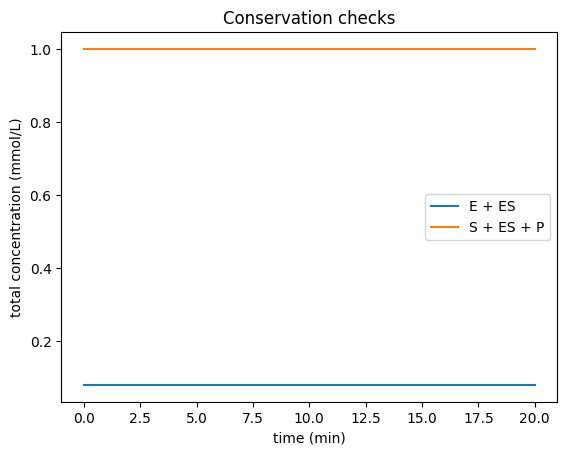

enzyme total at start = 0.080000
enzyme total at end   = 0.080000
substrate total at start = 1.000000
substrate total at end   = 1.000000


In [7]:
enzyme_total = E + ES
substrate_total = S + ES + P

plt.figure()
plt.plot(t, enzyme_total, label='E + ES')
plt.plot(t, substrate_total, label='S + ES + P')
plt.xlabel('time (min)')
plt.ylabel('total concentration (mmol/L)')
plt.title('Conservation checks')
plt.legend()
plt.show()

print(f'enzyme total at start = {enzyme_total[0]:.6f}')
print(f'enzyme total at end   = {enzyme_total[-1]:.6f}')
print(f'substrate total at start = {substrate_total[0]:.6f}')
print(f'substrate total at end   = {substrate_total[-1]:.6f}')

## מה קורה אם משנים את כמות האנזים?\n\nעכשיו נריץ את אותה סימולציה עבור כמה ריכוזי אנזים התחלתיים. הפעם נציג רק את התוצר, כדי שהגרף יישאר קריא.

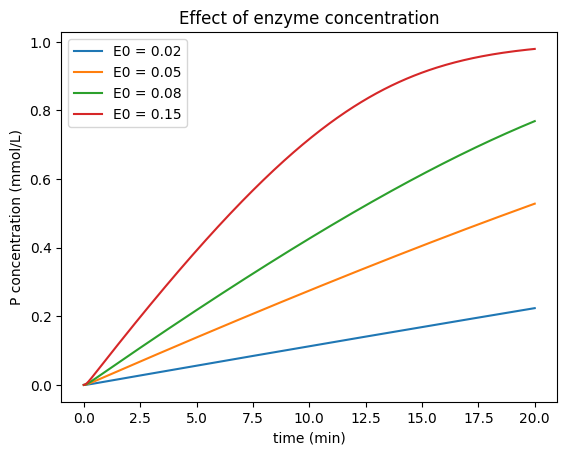

In [8]:
enzyme_initial_values = [0.02, 0.05, 0.08, 0.15]

plt.figure()
for E0 in enzyme_initial_values:
    y0 = [S0, E0, 0.0, 0.0]
    solution = solve_ivp(enzyme_rhs, time_span, y0, t_eval=t_eval)
    P = solution.y[3]
    plt.plot(solution.t, P, label=f'E0 = {E0}')

plt.xlabel('time (min)')
plt.ylabel('P concentration (mmol/L)')
plt.title('Effect of enzyme concentration')
plt.legend()
plt.show()

הכיוון הכללי ברור: יותר אנזים יוצר תוצר מהר יותר. אבל הצורה המדויקת של העקומות מתקבלת כאן מחישוב נומרי, לא מהצבה בנוסחה פשוטה אחת.

## תרגילים קצרים\n\n1. שנו את $k_\mathrm{cat}$ ובדקו איך משתנה קצב יצירת התוצר.\n2. שנו את $k_1$ ובדקו האם הקומפלקס $ES$ נוצר מהר יותר.\n3. נסו להקטין את ריכוז האנזים פי עשרה. האם עדיין מקבלים כמעט את כל התוצר תוך 20 דקות?\n4. הוסיפו גרף שמציג רק את $ES$ עבור כמה ערכי $k_1$.